In [1]:
                                        # CLUSTER PROJECT 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings("ignore")

In [3]:
world=pd.read_excel("World_development_mesurement.xlsx")
world

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,NaN,NaN,NaN,Turks and Caicos Islands,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,32427,0.911,NaN,NaN
2700,0.013,46.4%,NaN,United States,5.0,4.0,2132446.0,"$16,244,600,000,000",0.179,"$8,895",...,76.0,1.0,1,0.196,0.667,0.136,313873685,0.811,"$200,092,000,000","$126,573,000,000"
2701,0.015,41.9%,NaN,Uruguay,7.0,85.0,NaN,"$50,004,354,667",0.089,"$1,308",...,74.0,1.5,1,0.220,0.639,0.140,3395253,0.948,"$2,222,000,000","$1,028,000,000"
2702,0.020,61.9%,NaN,"Venezuela, RB",144.0,180.0,NaN,"$381,286,223,859",0.046,$593,...,72.0,1.0,1,0.288,0.652,0.060,29954782,0.889,"$904,000,000","$3,202,000,000"


In [4]:
world.info

<bound method DataFrame.info of       Birth Rate Business Tax Rate  CO2 Emissions                   Country  \
0          0.020               NaN        87931.0                   Algeria   
1          0.050               NaN         9542.0                    Angola   
2          0.043               NaN         1617.0                     Benin   
3          0.027               NaN         4276.0                  Botswana   
4          0.046               NaN         1041.0              Burkina Faso   
...          ...               ...            ...                       ...   
2699         NaN               NaN            NaN  Turks and Caicos Islands   
2700       0.013             46.4%            NaN             United States   
2701       0.015             41.9%            NaN                   Uruguay   
2702       0.020             61.9%            NaN             Venezuela, RB   
2703       0.011               NaN            NaN     Virgin Islands (U.S.)   

      Days to Start

In [5]:
world.shape

(2704, 25)

In [6]:
world.isnull().sum().sort_values(ascending=False)

Ease of Business          2519
Hours to do Tax           1288
Business Tax Rate         1281
Days to Start Business     986
Energy Usage               919
Lending Interest           824
CO2 Emissions              579
Tourism Outbound           471
Tourism Inbound            368
Health Exp/Capita          309
Health Exp % GDP           309
Infant Mortality Rate      260
Population 15-64           220
Population 65+             220
Population 0-14            220
GDP                        210
Internet Usage             173
Mobile Phone Usage         167
Life Expectancy Female     136
Life Expectancy Male       136
Birth Rate                 119
Population Urban            26
Country                      0
Number of Records            0
Population Total             0
dtype: int64

In [7]:
world.describe

<bound method NDFrame.describe of       Birth Rate Business Tax Rate  CO2 Emissions                   Country  \
0          0.020               NaN        87931.0                   Algeria   
1          0.050               NaN         9542.0                    Angola   
2          0.043               NaN         1617.0                     Benin   
3          0.027               NaN         4276.0                  Botswana   
4          0.046               NaN         1041.0              Burkina Faso   
...          ...               ...            ...                       ...   
2699         NaN               NaN            NaN  Turks and Caicos Islands   
2700       0.013             46.4%            NaN             United States   
2701       0.015             41.9%            NaN                   Uruguay   
2702       0.020             61.9%            NaN             Venezuela, RB   
2703       0.011               NaN            NaN     Virgin Islands (U.S.)   

      Days to Sta

In [8]:
#num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = world.select_dtypes(include='object').columns

#num_cols, 
cat_cols

Index(['Business Tax Rate', 'Country', 'GDP', 'Health Exp/Capita',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

In [9]:
world.select_dtypes(include='object').columns

Index(['Business Tax Rate', 'Country', 'GDP', 'Health Exp/Capita',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

In [10]:
numeric_like_cols = [col for col in cat_cols if col != 'Country']

In [11]:
numeric_like_cols

['Business Tax Rate',
 'GDP',
 'Health Exp/Capita',
 'Tourism Inbound',
 'Tourism Outbound']

In [12]:
world_clean = world.copy()

numeric_like_cols = []
for col in cat_cols:
    if col != 'Country':
        world_clean[col] = (
            world_clean[col]
            .astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.replace('%', '', regex=False)
            .str.strip()
        )
        world_clean[col] = pd.to_numeric(world_clean[col], errors='coerce')
        numeric_like_cols.append(col)

In [13]:
world_clean

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,5.479006e+10,0.035,60.0,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,1.020000e+08,1.930000e+08
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,9.129595e+09,0.034,22.0,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,3.400000e+07,1.460000e+08
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,2.359122e+09,0.043,15.0,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,7.700000e+07,5.000000e+07
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,5.788312e+09,0.047,152.0,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,2.270000e+08,2.090000e+08
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,2.610959e+09,0.051,12.0,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,2.300000e+07,3.000000e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,NaN,NaN,NaN,Turks and Caicos Islands,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,32427,0.911,NaN,NaN
2700,0.013,46.4,NaN,United States,5.0,4.0,2132446.0,1.624460e+13,0.179,8895.0,...,76.0,1.0,1,0.196,0.667,0.136,313873685,0.811,2.000920e+11,1.265730e+11
2701,0.015,41.9,NaN,Uruguay,7.0,85.0,NaN,5.000435e+10,0.089,1308.0,...,74.0,1.5,1,0.220,0.639,0.140,3395253,0.948,2.222000e+09,1.028000e+09
2702,0.020,61.9,NaN,"Venezuela, RB",144.0,180.0,NaN,3.812862e+11,0.046,593.0,...,72.0,1.0,1,0.288,0.652,0.060,29954782,0.889,9.040000e+08,3.202000e+09


In [14]:
num_cols = world_clean.select_dtypes(include=['int64', 'float64']).columns

In [15]:
print("Numeric columns:")
print(num_cols)

print("Object columns:")
print(world_clean.select_dtypes(include='object').columns)

Numeric columns:
Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions',
       'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP',
       'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax',
       'Infant Mortality Rate', 'Internet Usage', 'Lending Interest',
       'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage',
       'Number of Records', 'Population 0-14', 'Population 15-64',
       'Population 65+', 'Population Total', 'Population Urban',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')
Object columns:
Index(['Country'], dtype='object')


In [16]:
num_imputer = SimpleImputer(strategy='median')
world_clean[num_cols] = num_imputer.fit_transform(world_clean[num_cols])

In [17]:
world_clean.isnull().sum()

Birth Rate                0
Business Tax Rate         0
CO2 Emissions             0
Country                   0
Days to Start Business    0
Ease of Business          0
Energy Usage              0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Hours to do Tax           0
Infant Mortality Rate     0
Internet Usage            0
Lending Interest          0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Number of Records         0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64

In [18]:
import pandas as pd

world = pd.read_excel("World_development_mesurement.xlsx")

# Drop non-feature columns (example)
world = world.drop(columns=["Country", "Country Code"], errors="ignore")

# Convert percentage columns
for col in world.columns:
    world[col] = (
        world[col]
        .astype(str)
        .str.replace('%', '', regex=True)
    )

# Convert to numeric
world = world.apply(pd.to_numeric, errors="coerce")

# Handle missing values (DO NOT drop columns)
world = world.fillna(world.mean())

X = world.copy()

In [19]:
world_model = world_clean.drop(columns=['Country'])

In [20]:
log_cols = [
    'GDP',
    'CO2 Emissions',
    'Energy Usage',
    'Health Exp/Capita',
    'Tourism Inbound',
    'Tourism Outbound'
]

for col in log_cols:
    if col in world_model.columns:
        world_model[col] = np.log1p(world_model[col])

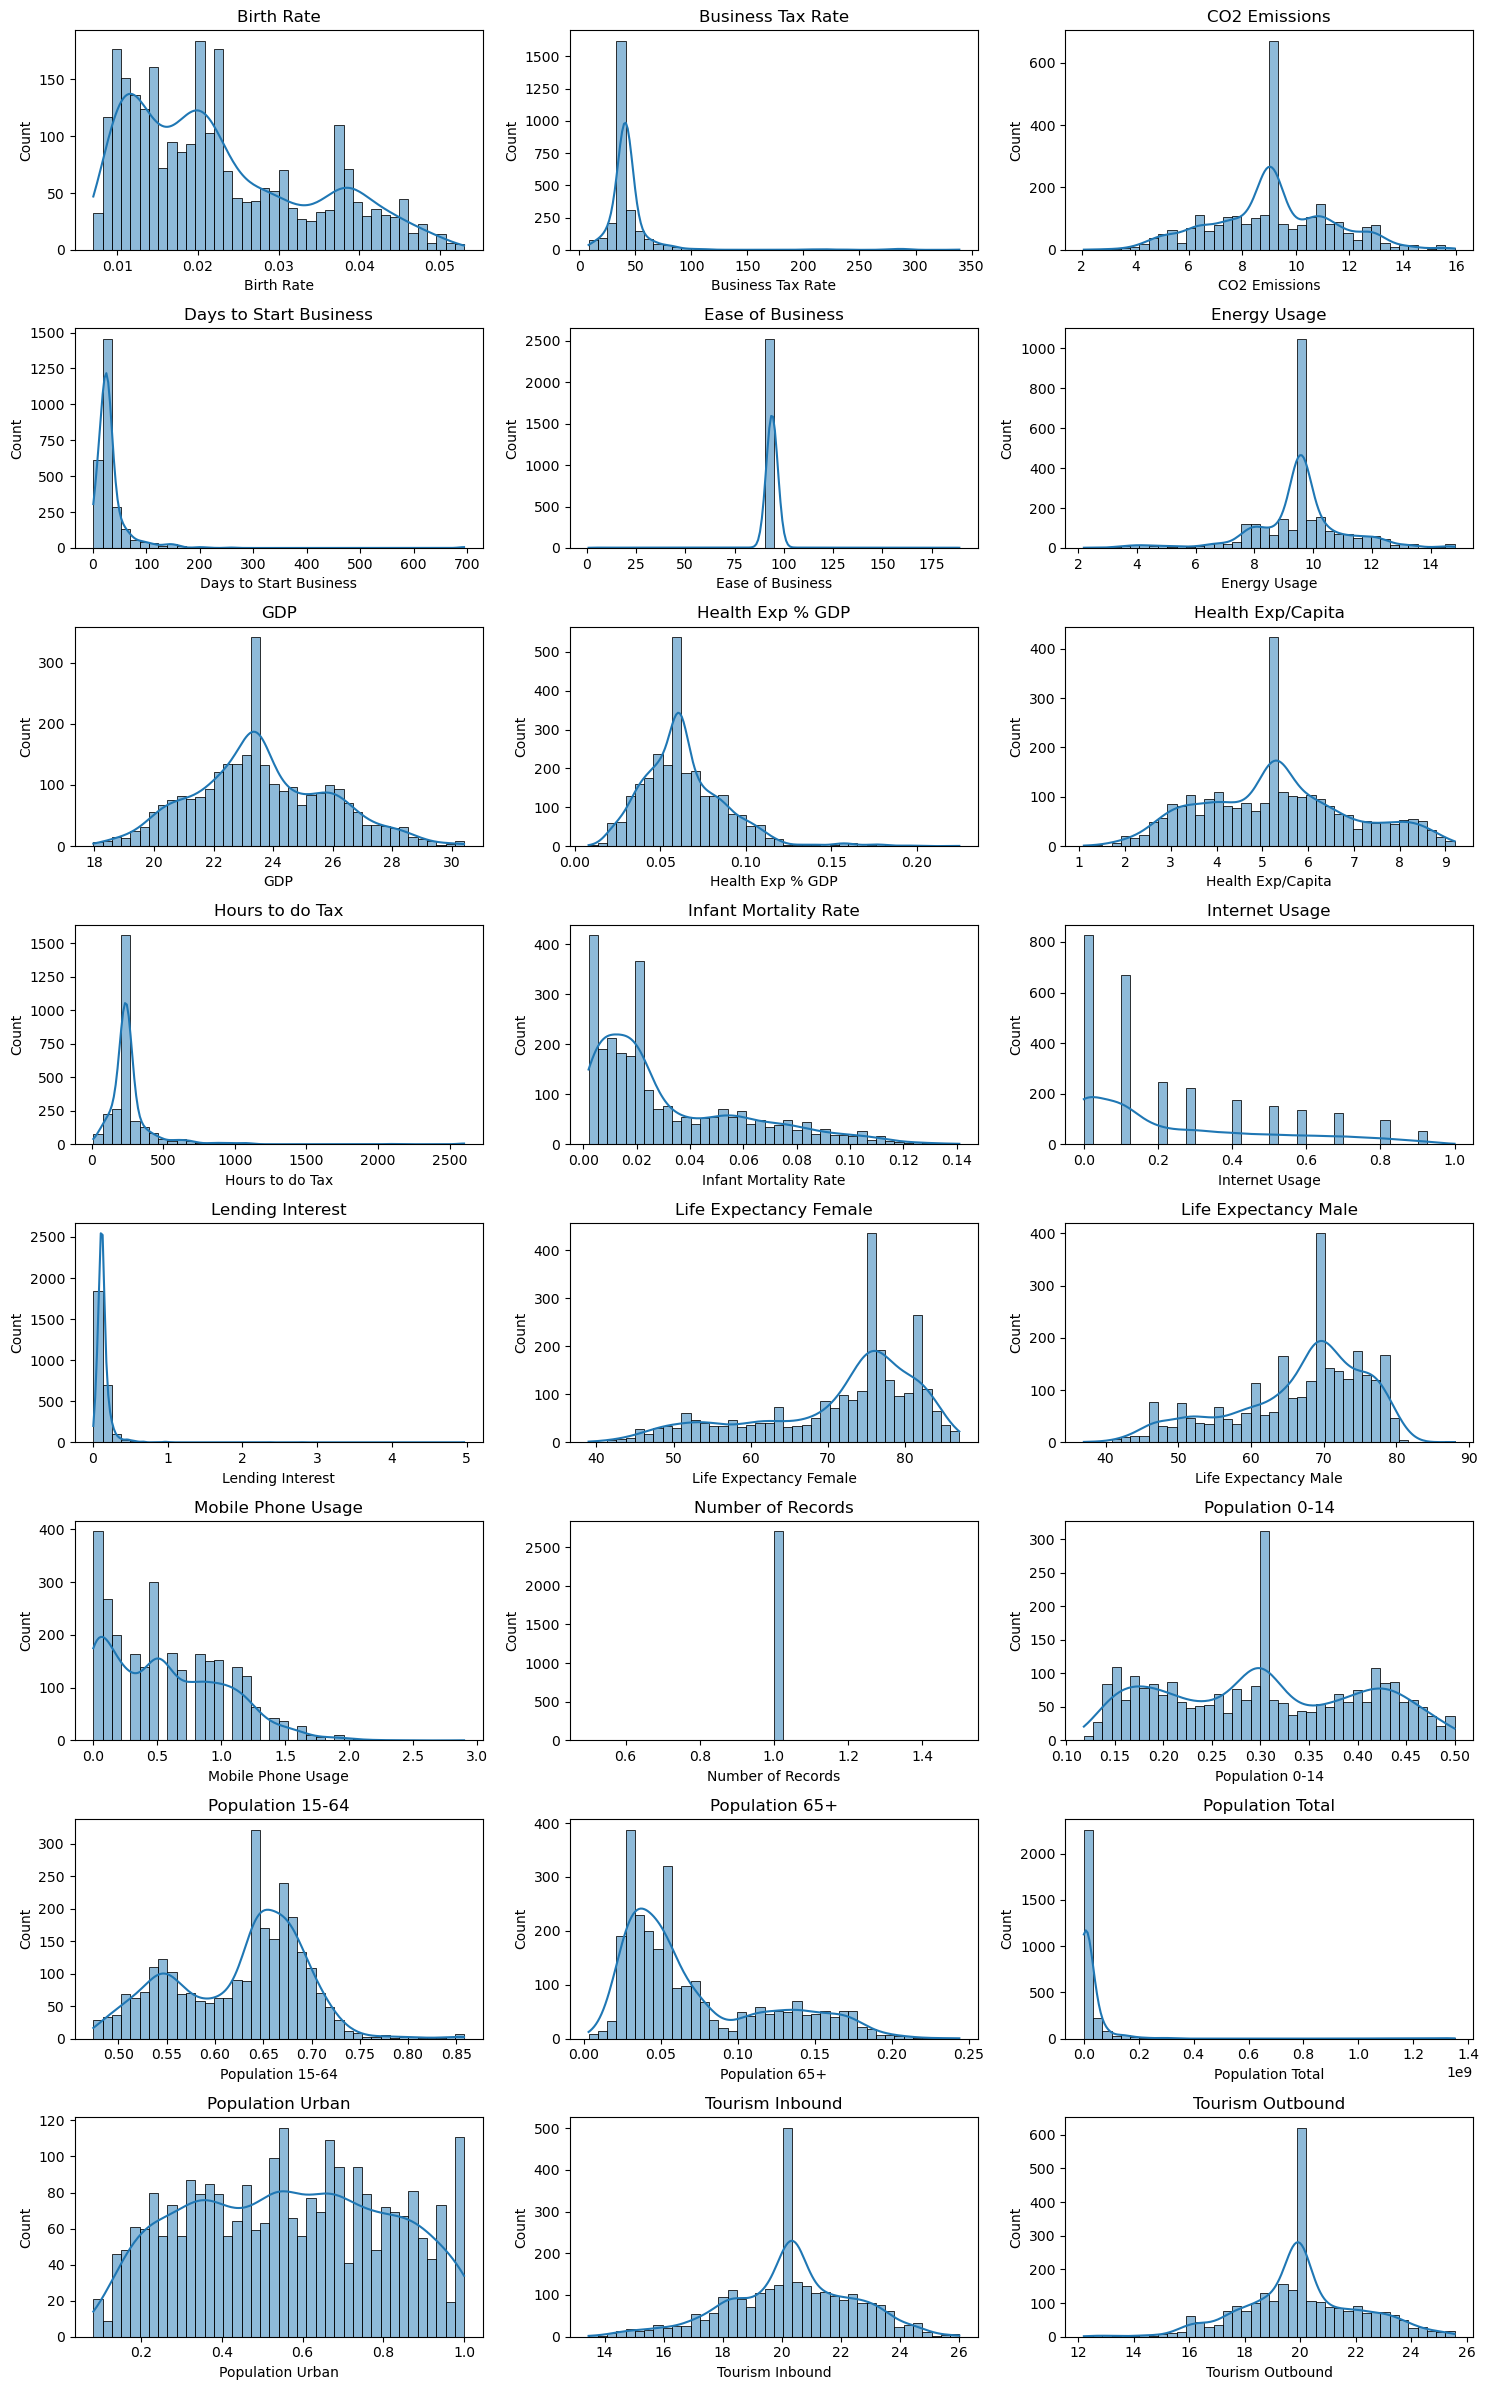

In [21]:
num_cols = world_model.select_dtypes(include = ['int64', 'float64']).columns
plot_df = world_model[num_cols]
sample_n = min(10000, plot_df.shape[0])
plot_sample = plot_df.sample(sample_n, random_state=42)

cols = 3
n = len(plot_sample.columns)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))
axes = axes.flatten()
for i, col in enumerate(plot_sample.columns):
    sns.histplot(plot_sample[col], ax=axes[i], kde=True, bins=40, color='C0')
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

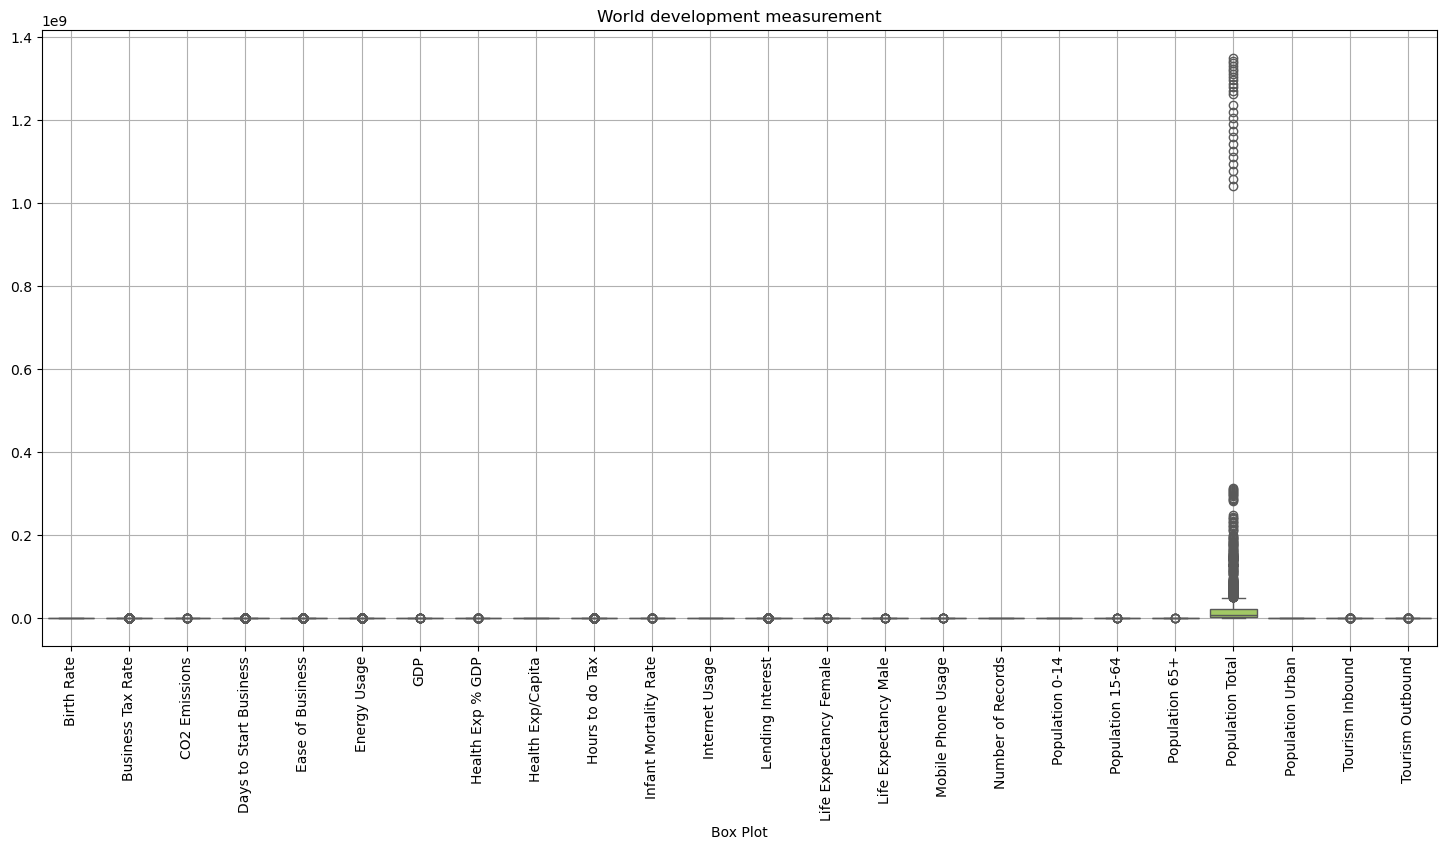

In [22]:
num_cols = world_model.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(18,8))
plt.xticks(rotation=90)
sns.boxplot(data=num_cols,palette='Set2')
plt.title("World development measurement")
plt.xlabel("Box Plot")
plt.grid(True)
plt.show()

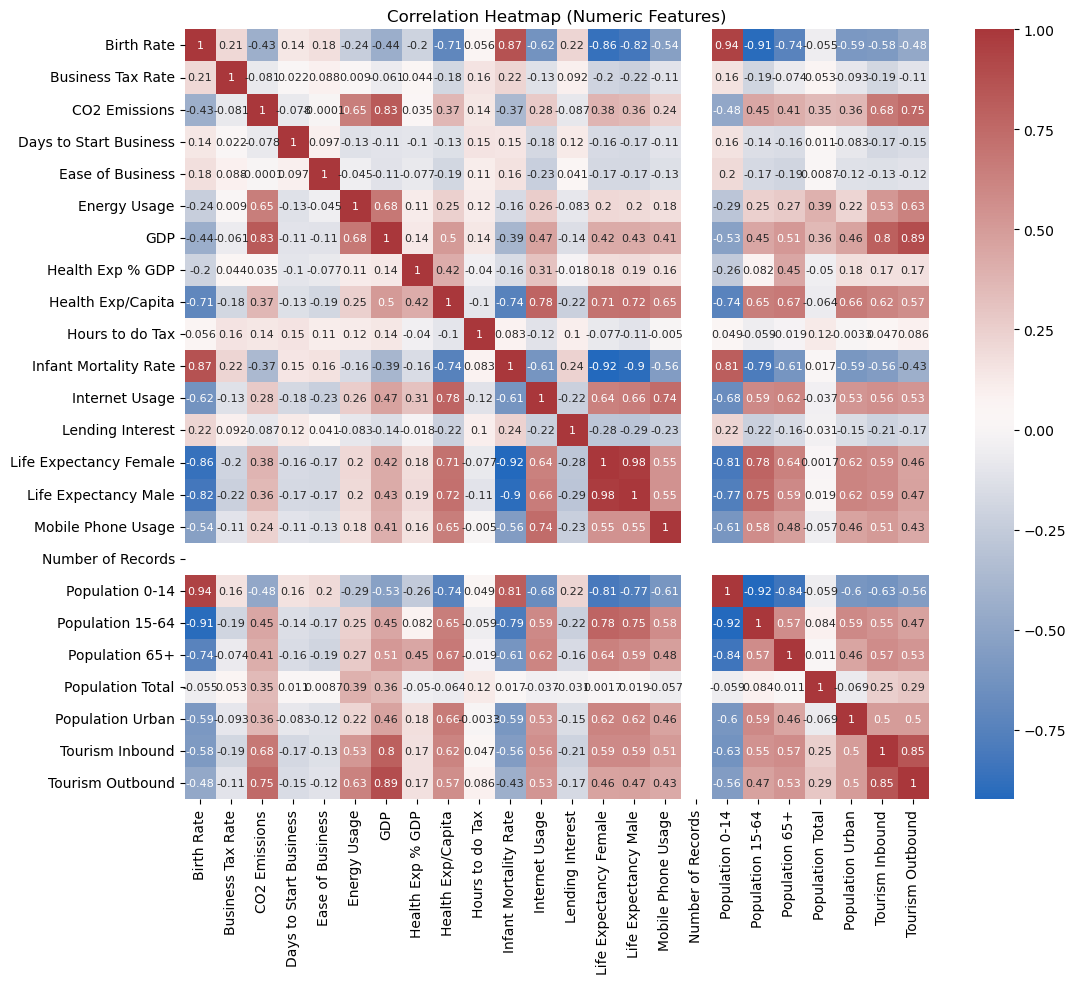

In [23]:
plt.figure(figsize=(12, 10))
sns.heatmap(world_model.corr(), cmap='vlag', annot=True,annot_kws={"size": 8})
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(world_model)

X_scaled = pd.DataFrame(X_scaled, columns=world_model.columns)

In [25]:
data = world.drop(columns=["GDP"])


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)


In [27]:
import numpy as np
np.isnan(scaled_data).sum()



np.int64(10816)

In [28]:
kmeans.fit(scaled_data)


NameError: name 'kmeans' is not defined

In [ ]:
                                            # KMEANS CLUSTER

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Step 1: Impute
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# Step 2: Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Step 3: KMeans
Kmean_data = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    Kmean_data.append(km.inertia_)

plt.figure(figsize =(6,4))
plt.plot(range(2,10),Kmean_data, marker = 'o',linestyle='--', color='b')
plt.xlabel("Number of Clusters")
plt.ylabel("Kmeans")
plt.grid(True)
plt.title("Elbow Methods of Kmeans")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters = 3, random_state=42)
world_model["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

In [ ]:
world_model.head()

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=pca_data,columns=['PC1','PC2'])
pca_df['KMeans_Cluster'] = world_model['KMeans_Cluster']

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=pca_df, palette='rocket')
plt.title('Country Segmentation based on Development Indicators')
plt.xlabel('PC1 (Economic Wealth)')
plt.ylabel('PC2 (Health & Education)')
plt.show()

In [ ]:
sil_Kmeans = silhouette_score(X_scaled,world_model['KMeans_Cluster'])
sil_Kmeans

In [ ]:
                            # HIERACHICAL CLUSTERING

In [ ]:
linked = linkage(X_scaled,method="ward")

plt.figure(figsize = (12, 6))
dendrogram(linked)
plt.title("Hierarchical Clustering")
plt.xlabel('countries')
plt.ylabel('Distance')
plt.show()

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [ ]:
np.isnan(X_scaled).sum()


In [ ]:
world_model = world.copy()

In [ ]:


# Numeric features only
numeric_df = world_model.select_dtypes(include=np.number)

imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(numeric_df)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [ ]:
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
world_model['Hierarchical_Cluster'] = hc.fit_predict(X_scaled)

world_model.groupby('Hierarchical_Cluster').mean()

In [ ]:
sil_hc = silhouette_score(X_scaled, world_model["Hierarchical_Cluster"])
sil_hc

In [ ]:
                         #DBSCAN CLUSTERING

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Drop cluster labels if already present
X = world_model.drop(columns=[
    'Hierarchical_Cluster',
    'DBSCAN_Cluster',
    'KMeans_Cluster',
    'GMM_Cluster',
    'Birch_Cluster'
], errors='ignore')

In [ ]:
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

In [ ]:
import numpy as np
np.isnan(X_imputed).sum()   # should be 0

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(8,4))
plt.plot(distances)
plt.ylabel("5-NN Distance")
plt.xlabel("Sorted points")
plt.title("K-distance graph for DBSCAN eps selection")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan = DBSCAN(eps=1.2, min_samples=5)
world_model['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# Remove noise for silhouette
labels = world_model['DBSCAN_Cluster']
mask = labels != -1

sil_dbscan = silhouette_score(X_scaled[mask], labels[mask])
print("DBSCAN Silhouette Score:", sil_dbscan)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels = dbscan.fit_predict(X_pca)

mask = labels != -1
sil_dbscan = silhouette_score(X_pca[mask], labels[mask])
print("DBSCAN (PCA) Silhouette:", sil_dbscan)

In [ ]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
world_model['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

In [ ]:
world_model['DBSCAN_Cluster'].value_counts

In [ ]:
mask = world_model['DBSCAN_Cluster'] != -1

if mask.sum() > 1:
    sil_dbscan = silhouette_score(
        X_scaled[mask],
        world_model.loc[mask, 'DBSCAN_Cluster']
    )
    sil_dbscan
else:
    sil_dbscan = "Not enough clusters"

In [ ]:
print(world_model.columns)

In [ ]:
feature_cols = [
    col for col in world_model.columns
    if col not in ['Hierarchical_Cluster', 'DBSCAN_Cluster']
]

X = world_model[feature_cols]

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [ ]:
from sklearn.cluster import KMeans, Birch
from sklearn.mixture import GaussianMixture

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
world_model['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# GMM
gmm = GaussianMixture(n_components=3, random_state=42)
world_model['GMM_Cluster'] = gmm.fit_predict(X_scaled)

# BIRCH
birch = Birch(n_clusters=3)
world_model['BIRCH_Cluster'] = birch.fit_predict(X_scaled)

In [ ]:
world_model.columns

In [ ]:
cluster_features = [
    col for col in world_model.columns
    if col not in [
        'KMeans_Cluster',
        'GMM_Cluster',
        'BIRCH_Cluster',
        'Hierarchical_Cluster',
        'DBSCAN_Cluster'
    ]
]

world_model.groupby('KMeans_Cluster')[cluster_features].mean()

In [ ]:
cluster_features = [
    col for col in world_model.columns
    if col not in [
        'KMeans_Cluster',
        'GMM_Cluster',
        'BIRCH_Cluster',
        'Hierarchical_Cluster'
    ]
]

In [ ]:
world_model.groupby('KMeans_Cluster')[cluster_features].mean()

In [ ]:
world_model.groupby('Hierarchical_Cluster')[cluster_features].mean()
world_model[world_model['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[cluster_features].mean()

In [ ]:

from sklearn.mixture import GaussianMixture

In [ ]:
gmm_scores = {}

for k in range(2, 10):
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    gmm_scores[k] = score

best_gmm_k = max(gmm_scores, key=gmm_scores.get)

gmm = GaussianMixture(n_components=best_gmm_k, random_state=42)
world['GMM_Cluster'] = gmm.fit_predict(X_scaled)

sil_gmm = gmm_scores[best_gmm_k]

In [ ]:
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.mixture import GaussianMixture

In [ ]:
from sklearn.cluster import Birch

In [ ]:
birch = Birch(n_clusters=3)
labels_birch = birch.fit_predict(X_scaled)

In [ ]:
sil_birch=silhouette_score(X_scaled, labels_birch)

In [ ]:
print("Silhouette Scores")
print("-----------------")
print("K-Means      :", sil_Kmeans)
print("Hierarchical :", sil_hc)
print("DBSCAN       :", sil_dbscan)
print("GMM          :", sil_gmm)
print("Birch     :",sil_birch )

In [ ]:
import pickle

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save models
with open("kmeans.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("gmm.pkl", "wb") as f:
    pickle.dump(gmm, f)

with open("birch.pkl", "wb") as f:
    pickle.dump(birch, f)

# Save DBSCAN
with open("dbscan.pkl", "wb") as f:
    pickle.dump(dbscan, f)

In [ ]:
feature_names = X.columns.tolist()

import pickle
pickle.dump(feature_names, open("feature_names.pkl", "wb"))

In [ ]:
feature_means = X.mean()

import pickle
with open("feature_means.pkl", "wb") as f:
    pickle.dump(feature_means, f)

In [ ]:
# Remove % sign and convert to numeric
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].str.replace('%', '', regex=True)

# Convert everything to numeric
X = X.apply(pd.to_numeric, errors='coerce')

In [ ]:
X = X.dropna(axis=1)

In [ ]:
print("Number of features:", X.shape[1])
print("Scaler expects:", scaler.n_features_in_)

In [ ]:
print(X.shape)   # MUST be (n_samples, 24)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
print(world.columns.tolist())

In [31]:
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import Birch

# Load dataset
df = pd.read_excel("World_development_mesurement.xlsx")

# Drop unwanted column
df = df.drop(columns=["Country"])

# Convert object columns to numeric
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].replace('[\$,]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Selected features
selected_features = [
    "GDP",
    "Life Expectancy Male",
    "Life Expectancy Female",
    "Infant Mortality Rate",
    "Internet Usage",
    "Population Total"
]

# Select only required columns
world = df[selected_features]

# Handle missing values
world = world.fillna(world.median())

# Scaling (IMPORTANT: scale world, not df)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(world)

# Train models
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_data)

gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(scaled_data)

birch = Birch(n_clusters=3)
birch.fit(scaled_data)

# Save models
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(kmeans, open("kmeans.pkl", "wb"))
pickle.dump(gmm, open("gmm.pkl", "wb"))
pickle.dump(birch, open("birch.pkl", "wb"))
pickle.dump(selected_features, open("feature_names.pkl", "wb"))

print("Training completed and pickle files saved.")



Training completed and pickle files saved.


In [32]:
selected_features = [
    "GDP",
    "Life Expectancy Male",
    "Life Expectancy Female",
    "Infant Mortality Rate",
    "Internet Usage",
    "Population Total"
]

df = df[selected_features]

pickle.dump(selected_features, open("feature_names.pkl", "wb"))

In [33]:
print("Saving these features:")
print(selected_features)
print(len(selected_features))

Saving these features:
['GDP', 'Life Expectancy Male', 'Life Expectancy Female', 'Infant Mortality Rate', 'Internet Usage', 'Population Total']
6


In [34]:
import pickle
print(pickle.load(open("feature_names.pkl","rb")))

['GDP', 'Life Expectancy Male', 'Life Expectancy Female', 'Infant Mortality Rate', 'Internet Usage', 'Population Total']
